In [1]:
!df -h
!du -sh ~/.cache/* 2>/dev/null
!du -sh /root/.cache/* 2>/dev/null
!du -sh /content/PixelRAG/.venv 2>/dev/null

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
/dev/sda1       119G   52G   67G  44% /opt/bin/.nvidia
tmpfs           6.4G   96K  6.4G   1% /var/colab
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
8.0K	/root/.cache/antigravity
36K	/root/.cache/matplotlib
56M	/root/.cache/node-gyp
8.0K	/root/.cache/antigravity
36K	/root/.cache/matplotlib
56M	/root/.cache/node-gyp


In [2]:
!rm -rf ~/.cache/pip
!rm -rf ~/.cache/uv
!rm -rf ~/.cache/huggingface/hub
!rm -rf ~/.cache/torch

In [3]:
!free -h
!nvidia-smi
!df -h /content

               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.3Gi       6.7Gi       2.0Mi       3.7Gi        10Gi
Swap:             0B          0B          0B
Thu Aug 27 04:50:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8        

In [4]:
import logging, sys, time, traceback, contextlib
from pathlib import Path

LOG_PATH = Path("pixelrag_run.log")
logger = logging.getLogger("pixelrag")
logger.setLevel(logging.DEBUG)
logger.handlers.clear()

_fmt = logging.Formatter("%(asctime)s | %(levelname)-7s | %(message)s", "%H:%M:%S")

_fh = logging.FileHandler(LOG_PATH, mode="a")
_fh.setLevel(logging.DEBUG)          # everything, including stack traces, goes to file
_fh.setFormatter(_fmt)

_ch = logging.StreamHandler(sys.stdout)
_ch.setLevel(logging.INFO)           # keep console readable, file has the full detail
_ch.setFormatter(_fmt)

logger.addHandler(_fh)
logger.addHandler(_ch)

def gpu_snapshot(tag: str = ""):
    """Best-effort GPU memory line. Never raises — a broken CUDA context
    (e.g. after a device-side assert) can itself throw here, and this must
    still be safe to call from inside an except block."""
    try:
        import torch
        if torch.cuda.is_available():
            free, total = torch.cuda.mem_get_info()
            logger.debug(
                f"[GPU{' ' + tag if tag else ''}] "
                f"used={(total - free) / 1e9:.2f}GB free={free / 1e9:.2f}GB total={total / 1e9:.2f}GB"
            )
        else:
            logger.debug(f"[GPU{' ' + tag if tag else ''}] CUDA not available")
    except Exception as e:
        logger.debug(f"[GPU] snapshot unavailable ({type(e).__name__}: {e})")

@contextlib.contextmanager
def stage(name: str, **ctx):
    """Wrap a block of work: logs start/end/duration, snapshots GPU memory
    before and after, and — critically — logs the FULL traceback on failure
    before re-raising, instead of letting Colab's short traceback or a
    swallowed `except Exception` hide what actually happened."""
    ctx_str = f" | {ctx}" if ctx else ""
    logger.info(f"START  {name}{ctx_str}")
    gpu_snapshot(name)
    t0 = time.time()
    try:
        yield
    except Exception:
        logger.error(f"FAIL   {name} after {time.time() - t0:.2f}s")
        logger.error(traceback.format_exc())
        gpu_snapshot(name + " (failed)")
        raise
    else:
        logger.info(f"DONE   {name} in {time.time() - t0:.2f}s")
        gpu_snapshot(name + " (done)")

logger.info("=" * 70)
logger.info("PixelRAG notebook run started — full log at ./pixelrag_run.log")
logger.info("=" * 70)


04:50:10 | INFO    | ======================================================================


INFO:pixelrag:======================================================================


04:50:10 | INFO    | PixelRAG notebook run started — full log at ./pixelrag_run.log


INFO:pixelrag:PixelRAG notebook run started — full log at ./pixelrag_run.log


04:50:10 | INFO    | ======================================================================


INFO:pixelrag:======================================================================


In [5]:
!free -h
!df -h /content
!nvidia-smi
import torch

with stage("gpu_check"):
    if not torch.cuda.is_available():
        logger.error("CUDA not available — nothing downstream (embedding, serving, "
                      "captioning) will work. In Colab: Runtime > Change runtime type > GPU.")
        raise RuntimeError("No CUDA device visible to torch.")
    logger.info(f"CUDA OK | device={torch.cuda.get_device_name(0)} | "
                f"capability={torch.cuda.get_device_capability(0)} | "
                f"torch={torch.__version__} | cuda_runtime={torch.version.cuda}")


               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.3Gi       6.7Gi       2.0Mi       3.7Gi        10Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   48G   66G  42% /
Thu Aug 27 04:50:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4             

INFO:pixelrag:START  gpu_check
DEBUG:pixelrag:[GPU gpu_check] used=0.11GB free=15.53GB total=15.64GB


04:50:15 | INFO    | CUDA OK | device=Tesla T4 | capability=(7, 5) | torch=2.11.0+cu128 | cuda_runtime=12.8


INFO:pixelrag:CUDA OK | device=Tesla T4 | capability=(7, 5) | torch=2.11.0+cu128 | cuda_runtime=12.8


04:50:15 | INFO    | DONE   gpu_check in 0.00s


INFO:pixelrag:DONE   gpu_check in 0.00s
DEBUG:pixelrag:[GPU gpu_check (done)] used=0.11GB free=15.53GB total=15.64GB


In [6]:
import subprocess
from pathlib import Path

with stage("clone_and_sync"):
    %cd /content
    repo = Path("/content/PixelRAG")
    if not repo.exists():
        clone = subprocess.run(
            ["git", "clone", "-q", "--depth", "1",
             "https://github.com/StarTrail-org/PixelRAG.git", "/content/PixelRAG"],
            capture_output=True, text=True,
        )
        if clone.returncode != 0:
            logger.error(f"git clone failed (code {clone.returncode}): {clone.stderr}")
            raise RuntimeError("PixelRAG clone failed — check network access / repo URL.")
        logger.info("Cloned PixelRAG OK")
    else:
        logger.info("PixelRAG already present — skipping re-clone")

    %cd /content/PixelRAG
    !pip install -q uv

    sync = subprocess.run(
        ["uv", "sync", "--extra", "embed", "--extra", "index", "--extra", "serve"],
        capture_output=True, text=True,
    )
    logger.debug(f"uv sync stdout:\n{sync.stdout[-3000:]}")
    if sync.returncode != 0:
        logger.error(f"uv sync failed (code {sync.returncode}): {sync.stderr[-3000:]}")
        raise RuntimeError("Dependency sync failed — see log for the last stderr chunk.")
    logger.info("uv sync OK")

    help_check = subprocess.run(["uv", "run", "pixelrag", "--help"], capture_output=True, text=True)
    if help_check.returncode != 0:
        logger.error(f"`pixelrag --help` failed — CLI not installed correctly: {help_check.stderr}")
        raise RuntimeError("pixelrag CLI not runnable after sync.")
    logger.info("pixelrag CLI available")

04:50:15 | INFO    | START  clone_and_sync


INFO:pixelrag:START  clone_and_sync
DEBUG:pixelrag:[GPU clone_and_sync] used=0.11GB free=15.53GB total=15.64GB


/content
04:50:18 | INFO    | Cloned PixelRAG OK


INFO:pixelrag:Cloned PixelRAG OK


/content/PixelRAG
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 28.5 MB/s eta 0:00:00


...

INFO:pixelrag:uv sync OK


04:52:30 | INFO    | pixelrag CLI available


INFO:pixelrag:pixelrag CLI available


04:52:30 | INFO    | DONE   clone_and_sync in 135.56s


INFO:pixelrag:DONE   clone_and_sync in 135.56s
DEBUG:pixelrag:[GPU clone_and_sync (done)] used=0.11GB free=15.53GB total=15.64GB


In [7]:
from google.colab import files
from pathlib import Path
import shutil

with stage("upload_docs"):
    DOCS = Path("my_docs")
    DOCS.mkdir(exist_ok=True)

    uploaded = files.upload()
    if not uploaded:
        logger.warning("No files were uploaded — the index build downstream will have nothing to index.")

    SUPPORTED = {".pdf", ".png", ".jpg", ".jpeg"}
    for name in uploaded:
        src_path = Path(name)
        dst_path = DOCS / src_path.name
        if src_path.suffix.lower() not in SUPPORTED:
            logger.warning(f"'{name}' has an unrecognized extension ({src_path.suffix}) — "
                            f"ingestion may skip it. Supported: {sorted(SUPPORTED)}")
        size_kb = src_path.stat().st_size / 1024
        if size_kb == 0:
            logger.warning(f"'{name}' uploaded as a 0-byte file — likely a failed upload.")
        if src_path.resolve() != dst_path.resolve():
            shutil.move(str(src_path), str(dst_path))
        logger.info(f"Corpus file: {dst_path}  ({size_kb:.1f} KB)")

    print("Corpus:")
    for p in sorted(DOCS.iterdir()):
        print(" ", p)


04:52:31 | INFO    | START  upload_docs


INFO:pixelrag:START  upload_docs
DEBUG:pixelrag:[GPU upload_docs] used=0.11GB free=15.53GB total=15.64GB


Saving img1.png to img1.png
Saving img2.png to img2.png
Saving img3.png to img3.png
04:53:05 | INFO    | Corpus file: my_docs/img1.png  (1085.9 KB)


INFO:pixelrag:Corpus file: my_docs/img1.png  (1085.9 KB)


04:53:05 | INFO    | Corpus file: my_docs/img2.png  (1526.2 KB)


INFO:pixelrag:Corpus file: my_docs/img2.png  (1526.2 KB)


04:53:05 | INFO    | Corpus file: my_docs/img3.png  (1593.6 KB)


INFO:pixelrag:Corpus file: my_docs/img3.png  (1593.6 KB)


Corpus:
  my_docs/img1.png
  my_docs/img2.png
  my_docs/img3.png
04:53:05 | INFO    | DONE   upload_docs in 34.82s


INFO:pixelrag:DONE   upload_docs in 34.82s
DEBUG:pixelrag:[GPU upload_docs (done)] used=0.11GB free=15.53GB total=15.64GB


In [8]:
from pathlib import Path

with stage("write_config"):
    config = """source:
  type: local
  path: ./my_docs

embed:
  model: Qwen/Qwen3-VL-Embedding-2B
  device: cuda
  gpu_ids: [0]
  backend: direct_gpu

tiling:
  width: 512
  height: 512
  overlap: 256

output: ./my_index
"""

    docs_dir = Path("my_docs")
    n_docs = len([p for p in docs_dir.iterdir() if p.is_file()]) if docs_dir.exists() else 0
    if n_docs == 0:
        logger.error("my_docs is empty — `pixelrag index build` will produce an empty index. "
                      "Re-run the upload cell before continuing.")
    else:
        logger.info(f"Config targets {n_docs} document(s) in {docs_dir.resolve()}")

    Path("pixelrag.yaml").write_text(config)
    logger.debug(f"Wrote pixelrag.yaml:\n{config}")
    print(config)


04:53:05 | INFO    | START  write_config


INFO:pixelrag:START  write_config
DEBUG:pixelrag:[GPU write_config] used=0.11GB free=15.53GB total=15.64GB


04:53:05 | INFO    | Config targets 3 document(s) in /content/PixelRAG/my_docs


INFO:pixelrag:Config targets 3 document(s) in /content/PixelRAG/my_docs
DEBUG:pixelrag:Wrote pixelrag.yaml:
source:
  type: local
  path: ./my_docs

embed:
  model: Qwen/Qwen3-VL-Embedding-2B
  device: cuda
  gpu_ids: [0]
  backend: direct_gpu

tiling:
  width: 512
  height: 512
  overlap: 256

output: ./my_index



source:
  type: local
  path: ./my_docs

embed:
  model: Qwen/Qwen3-VL-Embedding-2B
  device: cuda
  gpu_ids: [0]
  backend: direct_gpu

tiling:
  width: 512
  height: 512
  overlap: 256

output: ./my_index

04:53:05 | INFO    | DONE   write_config in 0.00s


INFO:pixelrag:DONE   write_config in 0.00s
DEBUG:pixelrag:[GPU write_config (done)] used=0.11GB free=15.53GB total=15.64GB


In [9]:
import subprocess

with stage("env_diagnostics"):
    !pwd
    !find . -maxdepth 2 -name pyproject.toml -print

    imp = subprocess.run(["uv", "run", "python", "-c", "import pixelrag; print(pixelrag.__file__)"],
                          capture_output=True, text=True)
    if imp.returncode != 0:
        logger.error(f"pixelrag package not importable inside uv env: {imp.stderr}")
        raise RuntimeError("pixelrag import failed — sync step likely didn't complete cleanly.")
    logger.info(f"pixelrag package resolves to: {imp.stdout.strip()}")

    !uv run pixelrag --help


04:53:05 | INFO    | START  env_diagnostics


INFO:pixelrag:START  env_diagnostics
DEBUG:pixelrag:[GPU env_diagnostics] used=0.11GB free=15.53GB total=15.64GB


/content/PixelRAG
./eval/pyproject.toml
./pyproject.toml
./train/pyproject.toml
04:53:06 | INFO    | pixelrag package resolves to: /content/PixelRAG/src/pixelrag/__init__.py


INFO:pixelrag:pixelrag package resolves to: /content/PixelRAG/src/pixelrag/__init__.py


usage: pixelrag <stage> [args...]

Pipeline stages:
  chunk         pixelrag_embed.chunk
  embed         pixelrag_embed.embed
  build-index   pixelrag_embed.index
  index         pixelrag_index.pipelines
  monitor       pixelrag_index.monitor
  serve         pixelrag_serve.api

Capture a page to screenshot tiles with the standalone `pixelshot` command.
Run `pixelrag <stage> --help` for a stage's own options.
04:53:06 | INFO    | DONE   env_diagnostics in 0.43s


INFO:pixelrag:DONE   env_diagnostics in 0.43s
DEBUG:pixelrag:[GPU env_diagnostics (done)] used=0.11GB free=15.53GB total=15.64GB


In [10]:
with stage("grep_sglang_dependency"):
    %cd /content/PixelRAG
    !grep -R "sglang" -n embed index src serve --exclude-dir=__pycache__ || true
    logger.info("sglang reference check complete (see cell output above for matches, if any)")


04:53:06 | INFO    | START  grep_sglang_dependency


INFO:pixelrag:START  grep_sglang_dependency
DEBUG:pixelrag:[GPU grep_sglang_dependency] used=0.11GB free=15.53GB total=15.64GB


/content/PixelRAG
embed/src/pixelrag_embed/embed.py:24:        --backend sglang \
embed/src/pixelrag_embed/embed.py:537:def _init_sglang(model_path: str, gpu_id: int, enforce_eager: bool = False):
embed/src/pixelrag_embed/embed.py:551:    from sglang.srt.entrypoints.engine import Engine
embed/src/pixelrag_embed/embed.py:575:def _get_tokenizer_sglang(engine):
embed/src/pixelrag_embed/embed.py:579:def _embed_sglang(engine, prompt: str, images: list["Image.Image"]) -> list[np.ndarray]:
embed/src/pixelrag_embed/embed.py:583:    Image data is passed as PIL Images (supported since sglang 0.5.x).
embed/src/pixelrag_embed/embed.py:587:    # L2 normalize (sglang encode() does not normalize internally)
embed/src/pixelrag_embed/embed.py:704:    The prompt arg is the chat template text (same format as sglang).
embed/src/pixelrag_embed/embed.py:753:    "sglang": (_init_sglang, _get_tokenizer_sglang, _embed_sglang),
embed/src/pixelrag_embed/embed.py:788:        backend: "vllm" or "sglang".
embed/src

INFO:pixelrag:sglang reference check complete (see cell output above for matches, if any)


04:53:06 | INFO    | DONE   grep_sglang_dependency in 0.11s


INFO:pixelrag:DONE   grep_sglang_dependency in 0.11s
DEBUG:pixelrag:[GPU grep_sglang_dependency (done)] used=0.11GB free=15.53GB total=15.64GB


In [11]:
import subprocess
from pathlib import Path

FORCE_REBUILD = False  # flip to True when docs/config actually changed

with stage("index_build"):
    idx = Path("my_index")
    already_built = idx.exists() and any(idx.rglob("*"))

    if already_built and not FORCE_REBUILD:
        n_files = sum(1 for p in idx.rglob("*") if p.is_file())
        logger.info(f"my_index already exists ({n_files} files) — skipping rebuild. "
                    f"Set FORCE_REBUILD=True to rebuild.")
    else:
        !rm -rf my_index
        build = subprocess.run(["uv", "run", "pixelrag", "index", "build"],
                                capture_output=True, text=True)
        logger.debug(f"index build stdout (tail):\n{build.stdout[-3000:]}")
        print(build.stdout[-3000:])
        if build.returncode != 0:
            logger.error(f"index build failed (code {build.returncode}): {build.stderr[-3000:]}")
            raise RuntimeError("Index build failed — see pixelrag_run.log for full stderr.")

        if not idx.exists() or not any(idx.rglob("*")):
            logger.error("index build reported success but my_index is missing/empty.")
            raise RuntimeError("Empty index after build — check my_docs had valid, supported files.")
        n_files = sum(1 for p in idx.rglob("*") if p.is_file())
        logger.info(f"Index build OK — {n_files} files written under {idx.resolve()}")

04:53:06 | INFO    | START  index_build


INFO:pixelrag:START  index_build
DEBUG:pixelrag:[GPU index_build] used=0.11GB free=15.53GB total=15.64GB
DEBUG:pixelrag:index build stdout (tail):
Found 1 shard files in my_index/embeddings

Merging and deduplicating shards...
Total raw vectors: 6, dim: 2048
Allocating 0.0 GB for float32 embeddings...
  [1/1] 6 vectors, 0s
Concat done: 6 vectors in 0s
Deduplicating...
Dedup done: 6 unique, 0 duplicates removed in 0.0s
Final: 6 × 2048
Saving metadata to my_index/metadata.npz...

Training IVF on CPU (nlist=1) on 6 vectors...
CPU training done in 0.0s
Adding 6 vectors...
  added 6/6 (0s, 63550 vec/s, ETA 0s)
Add done in 0.0s
Saving index to my_index/index.faiss...

Done! Index: 0.0 GB, metadata: 0.0 GB
Summary: my_index/summary.json



Found 1 shard files in my_index/embeddings

Merging and deduplicating shards...
Total raw vectors: 6, dim: 2048
Allocating 0.0 GB for float32 embeddings...
  [1/1] 6 vectors, 0s
Concat done: 6 vectors in 0s
Deduplicating...
Dedup done: 6 unique, 0 duplicates removed in 0.0s
Final: 6 × 2048
Saving metadata to my_index/metadata.npz...

Training IVF on CPU (nlist=1) on 6 vectors...
CPU training done in 0.0s
Adding 6 vectors...
  added 6/6 (0s, 63550 vec/s, ETA 0s)
Add done in 0.0s
Saving index to my_index/index.faiss...

Done! Index: 0.0 GB, metadata: 0.0 GB
Summary: my_index/summary.json

04:58:10 | INFO    | Index build OK — 21 files written under /content/PixelRAG/my_index


INFO:pixelrag:Index build OK — 21 files written under /content/PixelRAG/my_index


04:58:10 | INFO    | DONE   index_build in 303.99s


INFO:pixelrag:DONE   index_build in 303.99s
DEBUG:pixelrag:[GPU index_build (done)] used=0.11GB free=15.53GB total=15.64GB


In [12]:
from pathlib import Path

with stage("index_listing"):
    index = Path("my_index")
    total_bytes = 0
    n_files = 0
    for p in sorted(index.rglob("*")):
        if p.is_file():
            size = p.stat().st_size
            total_bytes += size
            n_files += 1
            print(f"{p}  {size / 1024:.1f} KB")
    logger.info(f"Index contents: {n_files} files, {total_bytes / 1e6:.2f} MB total")
    if n_files == 0:
        logger.warning("No files found under my_index — build likely failed silently upstream.")


04:58:10 | INFO    | START  index_listing


INFO:pixelrag:START  index_listing
DEBUG:pixelrag:[GPU index_listing] used=0.11GB free=15.53GB total=15.64GB


my_index/articles.json  0.2 KB
my_index/embeddings/checkpoint.json  0.0 KB
my_index/embeddings/shard_000.npz  30.1 KB
my_index/index.faiss  56.2 KB
my_index/metadata.npz  1.4 KB
my_index/summary.json  0.2 KB
my_index/tiles/0.png.tiles/chunk_0000_00.png  409.2 KB
my_index/tiles/0.png.tiles/chunk_0000_01.png  249.4 KB
my_index/tiles/0.png.tiles/chunks.json  0.5 KB
my_index/tiles/0.png.tiles/tile_0000.jpg  241.9 KB
my_index/tiles/0.png.tiles/tiles.json  0.1 KB
my_index/tiles/1.png.tiles/chunk_0000_00.png  598.4 KB
my_index/tiles/1.png.tiles/chunk_0000_01.png  353.6 KB
my_index/tiles/1.png.tiles/chunks.json  0.5 KB
my_index/tiles/1.png.tiles/tile_0000.jpg  294.3 KB
my_index/tiles/1.png.tiles/tiles.json  0.1 KB
my_index/tiles/2.png.tiles/chunk_0000_00.png  610.4 KB
my_index/tiles/2.png.tiles/chunk_0000_01.png  441.6 KB
my_index/tiles/2.png.tiles/chunks.json  0.5 KB
my_index/tiles/2.png.tiles/tile_0000.jpg  308.2 KB
my_index/tiles/2.png.tiles/tiles.json  0.1 KB
04:58:10 | INFO    | Index con

INFO:pixelrag:Index contents: 21 files, 3.68 MB total


04:58:10 | INFO    | DONE   index_listing in 0.00s


INFO:pixelrag:DONE   index_listing in 0.00s
DEBUG:pixelrag:[GPU index_listing (done)] used=0.11GB free=15.53GB total=15.64GB


In [13]:
with stage("index_ls"):
    !ls -lah my_index
    !find my_index -maxdepth 2 -type f | sort


04:58:10 | INFO    | START  index_ls


INFO:pixelrag:START  index_ls
DEBUG:pixelrag:[GPU index_ls] used=0.11GB free=15.53GB total=15.64GB


total 88K
drwxr-xr-x  4 root root 4.0K Aug 27 04:58 .
drwxr-xr-x 25 root root 4.0K Aug 27 04:53 ..
-rw-r--r--  1 root root  192 Aug 27 04:53 articles.json
drwxr-xr-x  2 root root 4.0K Aug 27 04:58 embeddings
-rw-r--r--  1 root root  57K Aug 27 04:58 index.faiss
-rw-r--r--  1 root root 1.5K Aug 27 04:58 metadata.npz
-rw-r--r--  1 root root  200 Aug 27 04:58 summary.json
drwxr-xr-x  5 root root 4.0K Aug 27 04:53 tiles
my_index/articles.json
my_index/embeddings/checkpoint.json
my_index/embeddings/shard_000.npz
my_index/index.faiss
my_index/metadata.npz
my_index/summary.json
04:58:10 | INFO    | DONE   index_ls in 0.21s


INFO:pixelrag:DONE   index_ls in 0.21s
DEBUG:pixelrag:[GPU index_ls (done)] used=0.11GB free=15.53GB total=15.64GB


In [14]:
import subprocess, time

with stage("server_launch"):
    cmd = ["uv", "run", "pixelrag", "serve",
           "--index-dir", "./my_index",
           "--tiles-dir", "./my_index/tiles",
           "--articles-json", "./my_index/articles.json",
           "--device", "cuda",
           "--port", "30001"]
    logger.info(f"Launching server: {' '.join(cmd)}")

    server = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
    )
    logger.info(f"Server PID {server.pid}")

    time.sleep(5)
    if server.poll() is not None:
        out = server.stdout.read()
        logger.error(f"Server exited immediately (code {server.poll()}):\n{out}")
        raise RuntimeError("pixelrag serve exited before startup — see log for its stdout/stderr.")
    logger.info("Server process alive after initial 5s check (still loading model)")


04:58:10 | INFO    | START  server_launch


INFO:pixelrag:START  server_launch
DEBUG:pixelrag:[GPU server_launch] used=0.11GB free=15.53GB total=15.64GB


04:58:10 | INFO    | Launching server: uv run pixelrag serve --index-dir ./my_index --tiles-dir ./my_index/tiles --articles-json ./my_index/articles.json --device cuda --port 30001


INFO:pixelrag:Launching server: uv run pixelrag serve --index-dir ./my_index --tiles-dir ./my_index/tiles --articles-json ./my_index/articles.json --device cuda --port 30001


04:58:10 | INFO    | Server PID 5388


INFO:pixelrag:Server PID 5388


04:58:15 | INFO    | Server process alive after initial 5s check (still loading model)


INFO:pixelrag:Server process alive after initial 5s check (still loading model)


04:58:15 | INFO    | DONE   server_launch in 5.01s


INFO:pixelrag:DONE   server_launch in 5.01s
DEBUG:pixelrag:[GPU server_launch (done)] used=0.11GB free=15.53GB total=15.64GB


In [15]:
import requests, time

with stage("server_health_check"):
    def wait_for_server(url="http://127.0.0.1:30001/status", timeout=180, interval=3):
        """Poll instead of guessing a fixed sleep — model load time varies a lot with
        cold HF downloads / disk cache state, which was a common source of 'random'
        failures further down the notebook (requests hitting a server that hadn't
        finished loading yet)."""
        start = time.time()
        last_err = None
        attempt = 0
        while time.time() - start < timeout:
            attempt += 1
            if server.poll() is not None:
                out = server.stdout.read()
                logger.error(f"Server died while waiting (code {server.poll()}):\n{out}")
                raise RuntimeError(f"pixelrag serve exited early (code {server.poll()}).")
            try:
                r = requests.get(url, timeout=5)
                r.raise_for_status()
                logger.info(f"Server ready after {attempt} attempt(s), {time.time()-start:.1f}s")
                return r.json()
            except requests.exceptions.RequestException as e:
                last_err = e
                logger.debug(f"[attempt {attempt}] server not ready yet: {e}")
                time.sleep(interval)
        logger.error(f"Server not ready after {timeout}s. Last error: {last_err}")
        raise TimeoutError(f"Server not ready after {timeout}s. Last error: {last_err}")

    status = wait_for_server()
    print(status)


04:58:15 | INFO    | START  server_health_check


INFO:pixelrag:START  server_health_check
DEBUG:pixelrag:[GPU server_health_check] used=0.11GB free=15.53GB total=15.64GB
DEBUG:pixelrag:[attempt 1] server not ready yet: HTTPConnectionPool(host='127.0.0.1', port=30001): Max retries exceeded with url: /status (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7b457e76d940>: Failed to establish a new connection: [Errno 111] Connection refused'))
DEBUG:pixelrag:[attempt 2] server not ready yet: HTTPConnectionPool(host='127.0.0.1', port=30001): Max retries exceeded with url: /status (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7b457e779590>: Failed to establish a new connection: [Errno 111] Connection refused'))
DEBUG:pixelrag:[attempt 3] server not ready yet: HTTPConnectionPool(host='127.0.0.1', port=30001): Max retries exceeded with url: /status (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7b457e779e50>: Failed to establish a new connection: [Err

04:58:34 | INFO    | Server ready after 7 attempt(s), 18.1s


INFO:pixelrag:Server ready after 7 attempt(s), 18.1s


{'total_vectors': 6, 'dimension': 2048, 'nlist': 1, 'nprobe': 128, 'model': 'Qwen/Qwen3-VL-Embedding-2B', 'index_dir': './my_index', 'tiles_dir': './my_index/tiles', 'index_built_at': '2026-08-27T04:58:10.343894+00:00', 'index_size_bytes': 57539, 'metadata_size_bytes': 1440}
04:58:34 | INFO    | DONE   server_health_check in 18.06s


INFO:pixelrag:DONE   server_health_check in 18.06s
DEBUG:pixelrag:[GPU server_health_check (done)] used=4.48GB free=11.16GB total=15.64GB


In [16]:
queries = [
    # Structural hierarchy & spatial grouping
    "Which microservices are grouped inside the Customer & Orders boundary, and which of those microservices have direct connections to components located outside their home boundary?",
    "In the Factory Systems region, identify the internal sub-components of Plant A and Plant B, and list all cross-connections between components in Plant A and components in Plant B.",
    "Which databases belong strictly to the Data Storage & Messaging layer, and which databases are embedded directly within service-specific bounded contexts?",
    "What are all the visual entry points crossing from the User Entry Points cluster into the Inventory & Catalog subsystem without passing through the primary API Gateway?",

    # Multi-hop data & control flow paths
    "Trace the complete downstream path starting from Mobile App API to Order Service. What intermediate components are traversed, and what persistent store does Order Service write to?",
    "Identify the complete data flow path starting from Order Service publishing an event to Apache Kafka Cluster / Kafka Message Bus. Which exact topic/consumer endpoints consume this message, and what secondary databases get updated as a result?",
    "Trace the flow from API Gateway down to Fulfillment Service. Contrast the direct path via Payment Gateway Adapter with the path mediated through Fraud Detection Service.",
    "What is the exact query/read flow path between Inventory Service, Stock Cache (Redis), and Inventory DB?",

    # Dependency, topology & graph analytics
    "Which service node in the graph exhibits the highest combined in-degree and out-degree? List its immediate structural neighbors across all directions.",
    "Identify if there is a cyclic directional loop involving Order Service, Auth Service, Cart Service, and Payment Gateway Adapter. List the exact sequence of directed edges forming the cycle.",
    "If Inventory DB becomes unreachable or drops connection",
]
logger.info(f"Loaded {len(queries)} predefined queries")


04:58:34 | INFO    | Loaded 11 predefined queries


INFO:pixelrag:Loaded 11 predefined queries


04:58:34 | INFO    | START  show_top_k_batch | {'n_queries': 11, 'k': 1}


INFO:pixelrag:START  show_top_k_batch | {'n_queries': 11, 'k': 1}
DEBUG:pixelrag:[GPU show_top_k_batch] used=4.48GB free=11.16GB total=15.64GB


QUERY: Which microservices are grouped inside the Customer & Orders boundary, and which of those microservices have direct connections to components located outside their home boundary?

#1 score=0.4870 article=0 tile=0 chunk=0


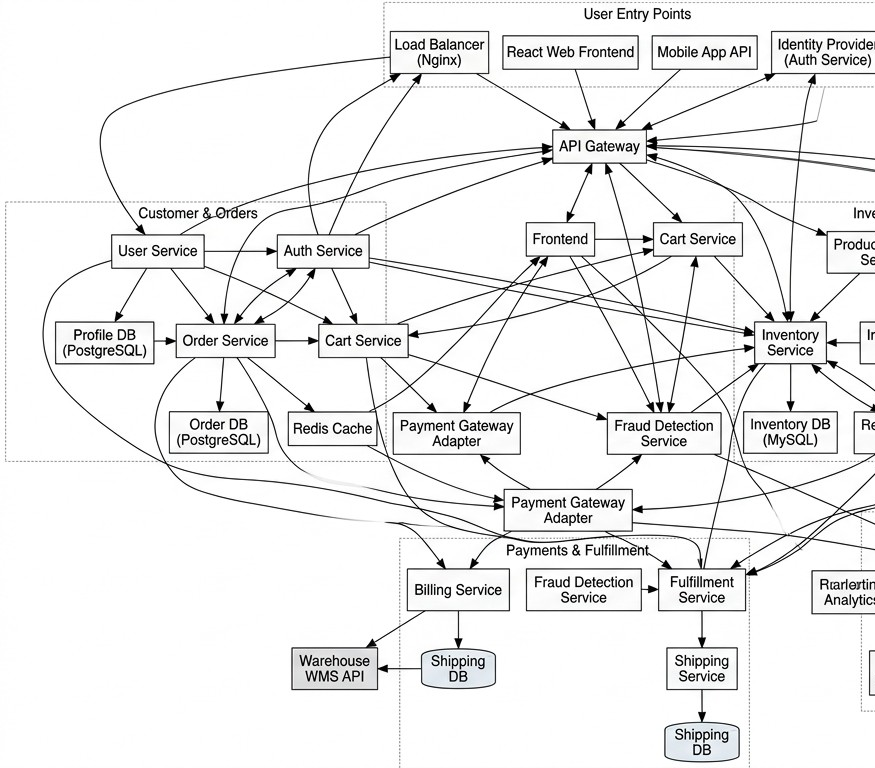


QUERY: In the Factory Systems region, identify the internal sub-components of Plant A and Plant B, and list all cross-connections between components in Plant A and components in Plant B.

#1 score=0.4403 article=2 tile=0 chunk=0


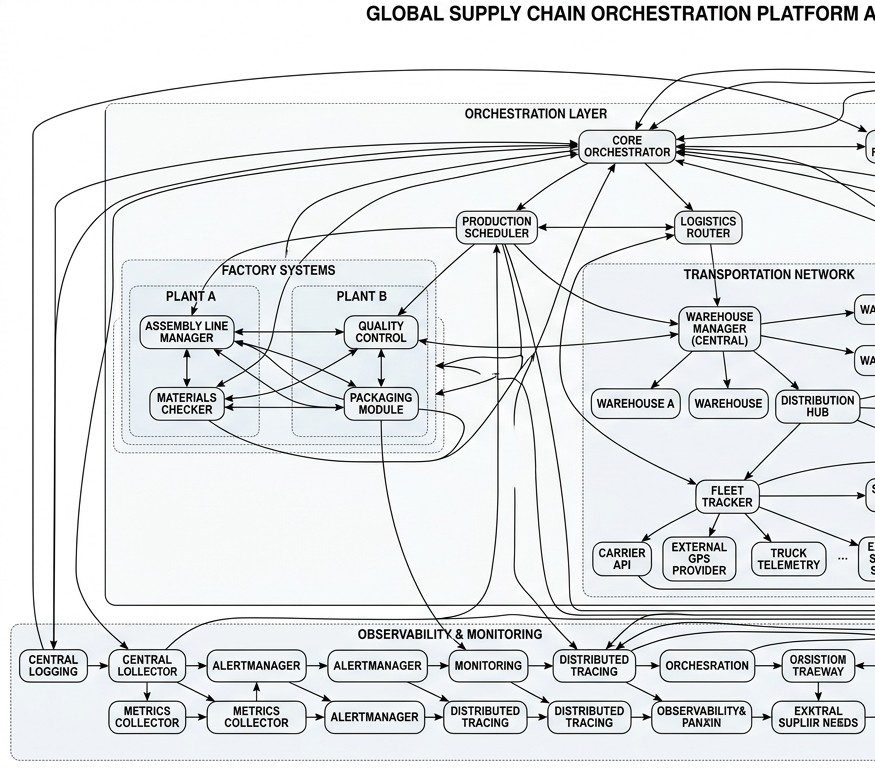


QUERY: Which databases belong strictly to the Data Storage & Messaging layer, and which databases are embedded directly within service-specific bounded contexts?

#1 score=0.5241 article=2 tile=0 chunk=1


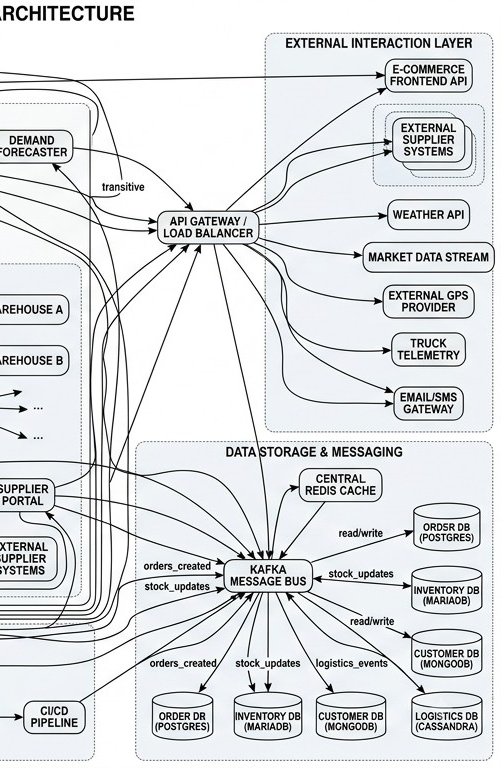


QUERY: What are all the visual entry points crossing from the User Entry Points cluster into the Inventory & Catalog subsystem without passing through the primary API Gateway?

#1 score=0.4977 article=0 tile=0 chunk=0


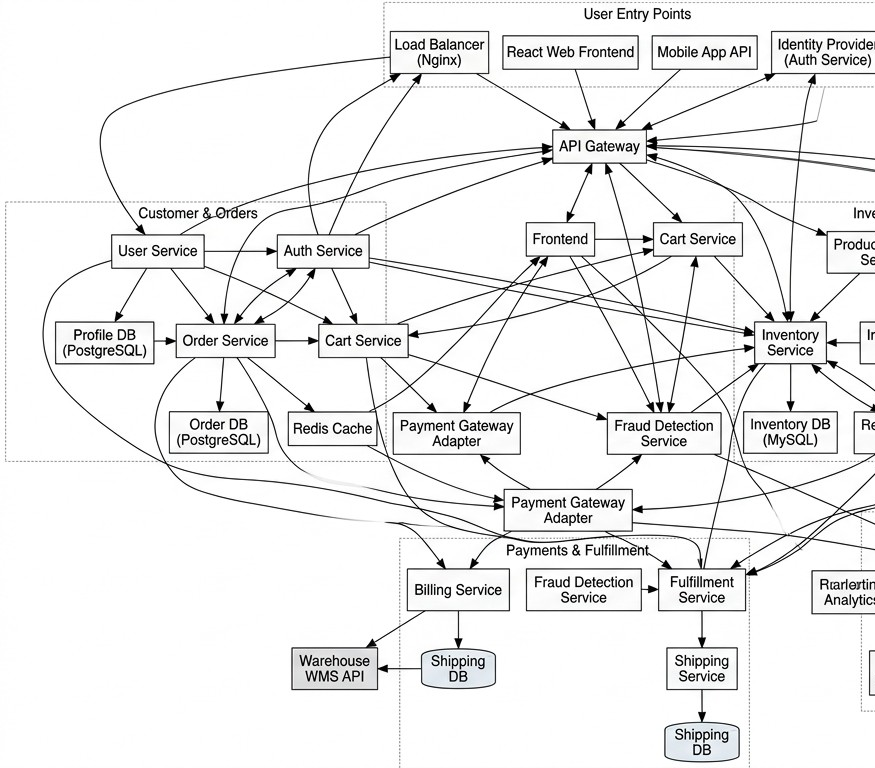


QUERY: Trace the complete downstream path starting from Mobile App API to Order Service. What intermediate components are traversed, and what persistent store does Order Service write to?

#1 score=0.5551 article=1 tile=0 chunk=0


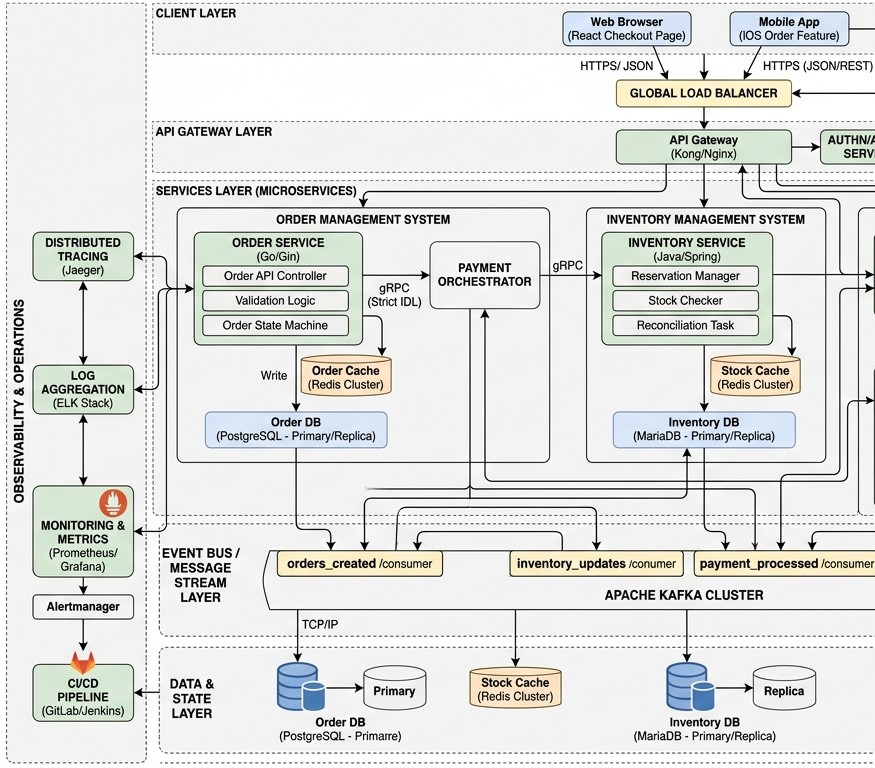


QUERY: Identify the complete data flow path starting from Order Service publishing an event to Apache Kafka Cluster / Kafka Message Bus. Which exact topic/consumer endpoints consume this message, and what secondary databases get updated as a result?

#1 score=0.5811 article=1 tile=0 chunk=0


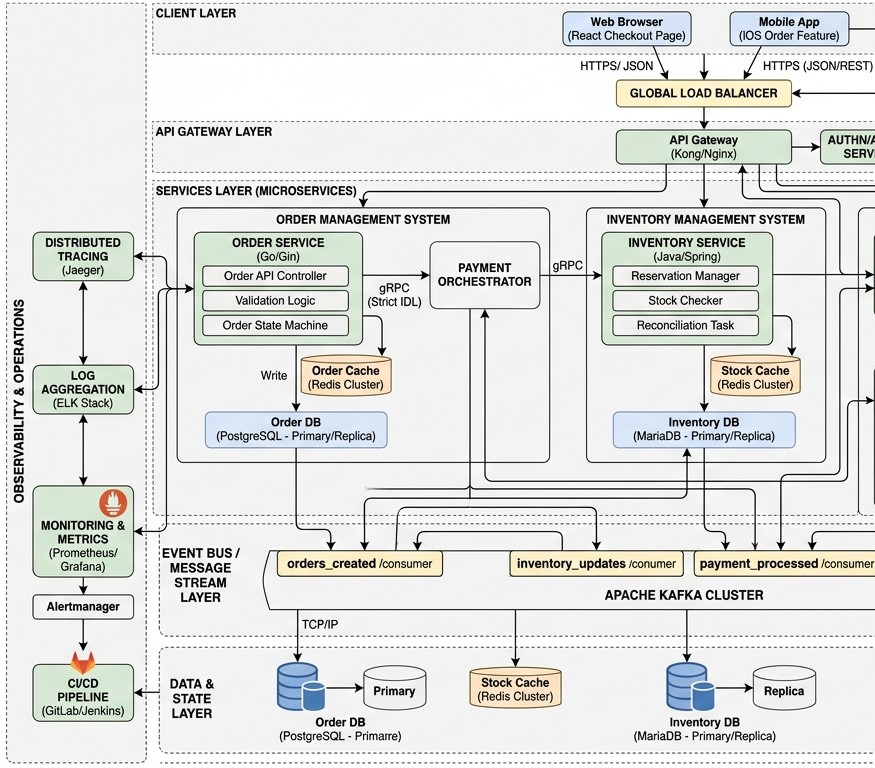


QUERY: Trace the flow from API Gateway down to Fulfillment Service. Contrast the direct path via Payment Gateway Adapter with the path mediated through Fraud Detection Service.

#1 score=0.5704 article=0 tile=0 chunk=0


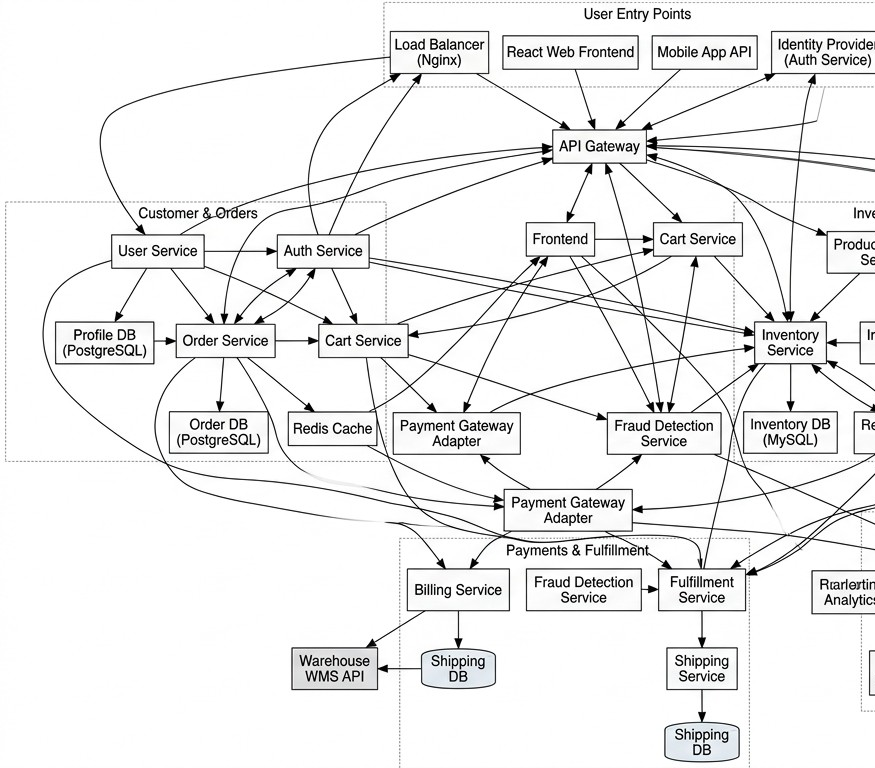


QUERY: What is the exact query/read flow path between Inventory Service, Stock Cache (Redis), and Inventory DB?

#1 score=0.5270 article=1 tile=0 chunk=0


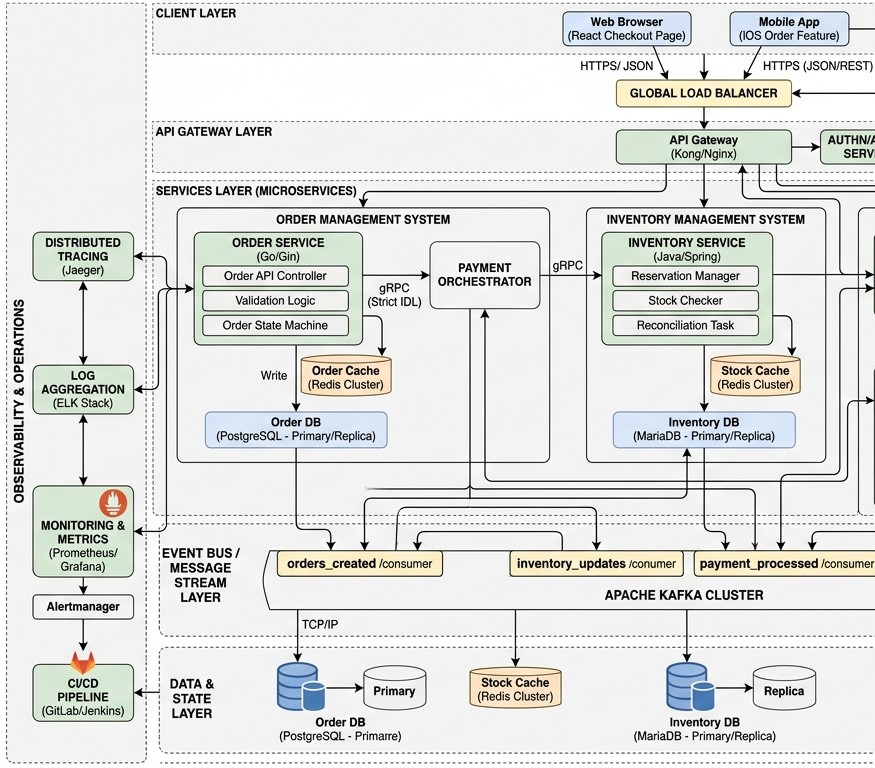


QUERY: Which service node in the graph exhibits the highest combined in-degree and out-degree? List its immediate structural neighbors across all directions.

#1 score=0.3930 article=0 tile=0 chunk=0


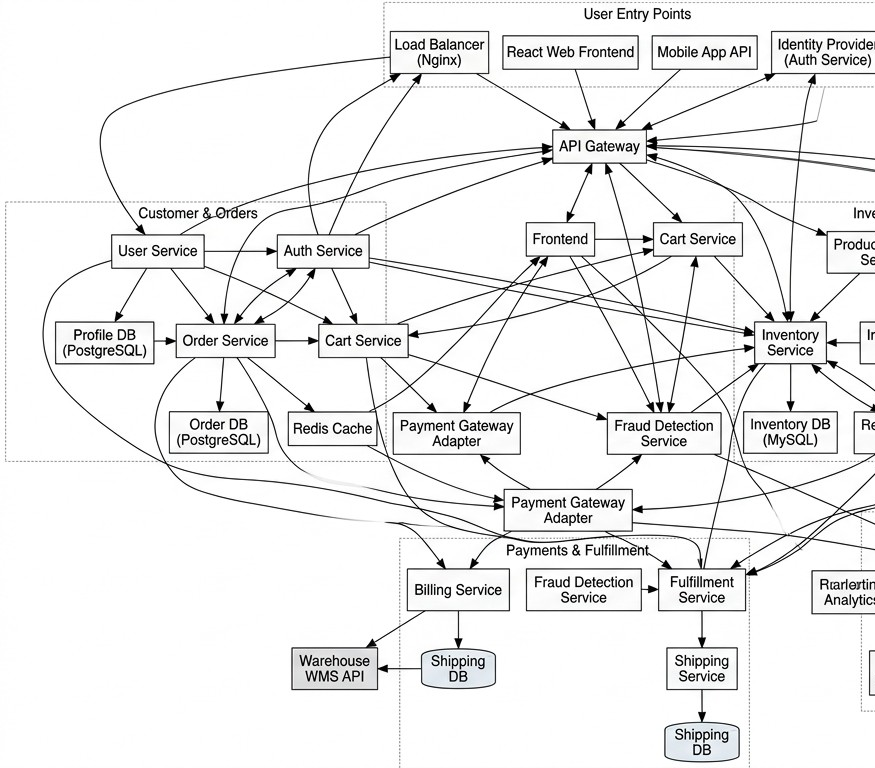


QUERY: Identify if there is a cyclic directional loop involving Order Service, Auth Service, Cart Service, and Payment Gateway Adapter. List the exact sequence of directed edges forming the cycle.

#1 score=0.5934 article=0 tile=0 chunk=0


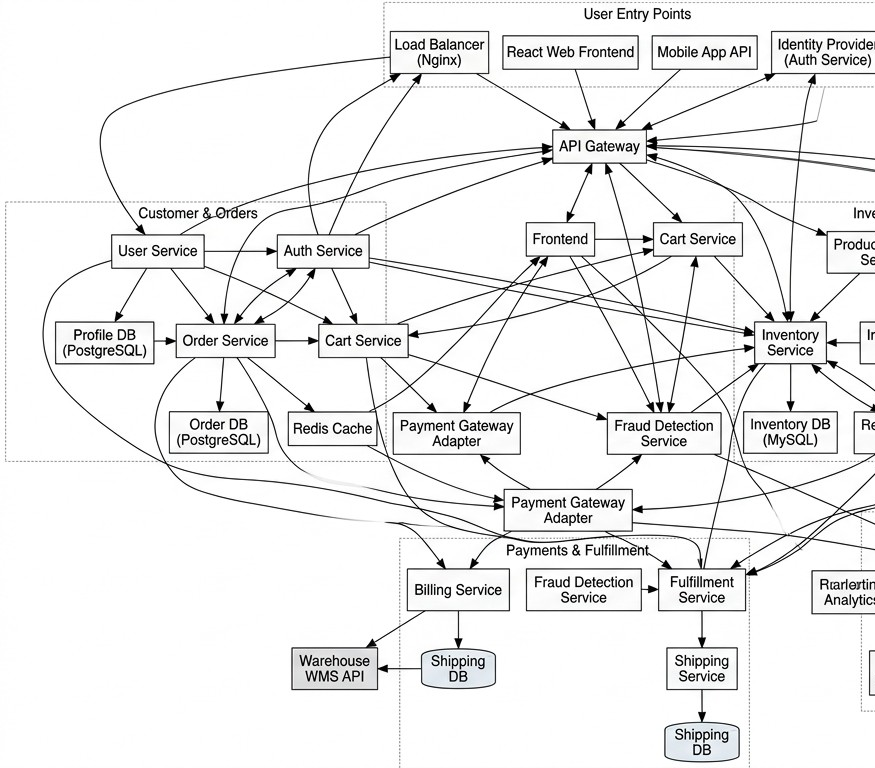


QUERY: If Inventory DB becomes unreachable or drops connection

#1 score=0.3586 article=1 tile=0 chunk=0


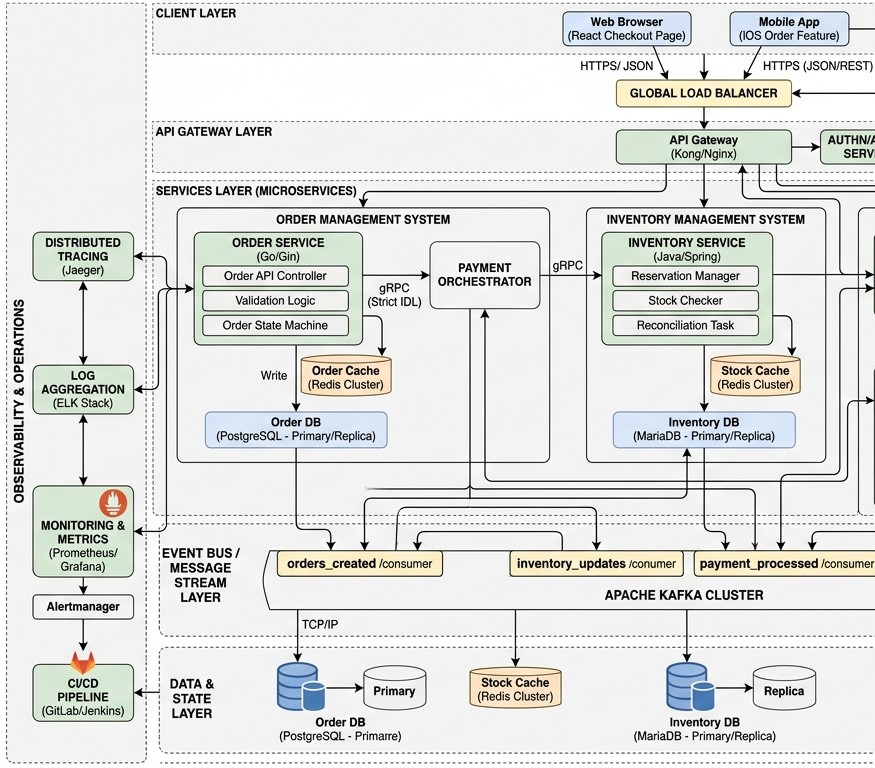


04:58:36 | INFO    | DONE   show_top_k_batch in 2.39s


INFO:pixelrag:DONE   show_top_k_batch in 2.39s
DEBUG:pixelrag:[GPU show_top_k_batch (done)] used=4.59GB free=11.05GB total=15.64GB


In [17]:
from IPython.display import Image, display

def show_top_k_batch(query_list: list[str], k: int = 1):
    with stage("show_top_k_batch", n_queries=len(query_list), k=k):
        try:
            r = requests.post(
                "http://127.0.0.1:30001/search",
                json={"queries": [{"text": q} for q in query_list], "n_docs": k},
                timeout=120,
            )
            r.raise_for_status()
        except requests.exceptions.RequestException as e:
            logger.error(f"/search request failed: {e}")
            raise
        response = r.json()

        for query, result in zip(query_list, response["results"]):
            print("QUERY:", query)
            hits = result.get("hits", [])
            if not hits:
                logger.warning(f"No hits returned for query: {query!r}")
            for rank, hit in enumerate(hits, 1):
                print(
                    f"\n#{rank} score={hit['score']:.4f} "
                    f"article={hit['article_id']} "
                    f"tile={hit['tile_index']} "
                    f"chunk={hit['chunk_index']}"
                )
                tile_url = (
                    "http://127.0.0.1:30001/tile/"
                    f"{hit['article_id']}/{hit['tile_index']}/{hit['chunk_index']}"
                )
                try:
                    image = requests.get(tile_url, timeout=30)
                    image.raise_for_status()
                    display(Image(data=image.content, width=700))
                except requests.exceptions.RequestException as e:
                    logger.error(f"Failed to fetch tile image {tile_url}: {e}")
                    print(f"[image fetch failed: {e}]")
            print("\n" + "=" * 80)

show_top_k_batch(queries, 1)


In [18]:
queries_input = []
while True:
    q = input("Enter query (blank to stop): ").strip()
    if not q:
        break
    queries_input.append(q)

# Guard: if nothing was typed, fall back to the pre-built query list from
# earlier (cell 12) instead of leaving `queries` empty — an empty list here
# is exactly what made `queries[0]` in the final cell raise IndexError.
queries = queries_input if queries_input else queries
if not queries_input:
    logger.warning("No queries entered interactively — falling back to the predefined query list.")
else:
    logger.info(f"Using {len(queries_input)} manually entered queries")

def search(query: str, n_docs: int = 5, retries: int = 2):
    last_err = None
    for attempt in range(retries + 1):
        try:
            r = requests.post(
                "http://127.0.0.1:30001/search",
                json={"queries": [{"text": query}], "n_docs": n_docs},
                timeout=120,
            )
            r.raise_for_status()
            return r.json()
        except requests.exceptions.RequestException as e:
            last_err = e
            logger.warning(f"search() attempt {attempt+1}/{retries+1} failed for {query!r}: {e}")
            if attempt < retries:
                time.sleep(2)
    logger.error(f"search() gave up after {retries+1} attempts: {last_err}")
    raise RuntimeError(f"search() failed after {retries+1} attempts against pixelrag server: {last_err}")

for query in queries:
    with stage("search", query=query[:60]):
        result = search(query, 5)
        hits = result["results"][0]["hits"]
        if not hits:
            logger.warning(f"Zero hits for query: {query!r}")
        print(f"\nQUERY: {query}")
        for rank, hit in enumerate(hits, 1):
            print(
                f"{rank}. score={hit['score']:.4f} | "
                f"article={hit['article_id']} | "
                f"tile={hit['tile_index']} | "
                f"chunk={hit['chunk_index']} | "
                f"path={hit['path']}"
            )


Enter query (blank to stop): Trace the complete downstream path starting from Mobile App API to Order Service. What intermediate components are traversed, and what persistent store does Order Service write to?
Enter query (blank to stop): 
04:58:47 | INFO    | Using 1 manually entered queries


INFO:pixelrag:Using 1 manually entered queries


04:58:48 | INFO    | START  search | {'query': 'Trace the complete downstream path starting from Mobile App '}


INFO:pixelrag:START  search | {'query': 'Trace the complete downstream path starting from Mobile App '}
DEBUG:pixelrag:[GPU search] used=4.59GB free=11.05GB total=15.64GB



QUERY: Trace the complete downstream path starting from Mobile App API to Order Service. What intermediate components are traversed, and what persistent store does Order Service write to?
1. score=0.5551 | article=1 | tile=0 | chunk=0 | path=1.png.tiles/chunk_0000_00.png
2. score=0.5368 | article=0 | tile=0 | chunk=0 | path=0.png.tiles/chunk_0000_00.png
3. score=0.4515 | article=1 | tile=0 | chunk=1 | path=1.png.tiles/chunk_0000_01.png
4. score=0.4344 | article=2 | tile=0 | chunk=1 | path=2.png.tiles/chunk_0000_01.png
5. score=0.3721 | article=0 | tile=0 | chunk=1 | path=0.png.tiles/chunk_0000_01.png
04:58:48 | INFO    | DONE   search in 0.24s


INFO:pixelrag:DONE   search in 0.24s
DEBUG:pixelrag:[GPU search (done)] used=4.59GB free=11.04GB total=15.64GB


In [19]:
from huggingface_hub import login
from google.colab import userdata

with stage("hf_login"):
    HF_TOKEN = userdata.get("HF_TOKEN")
    if not HF_TOKEN:
        logger.error("HF_TOKEN secret is empty/missing in Colab userdata — "
                      "add it via the key icon in the left sidebar before continuing.")
        raise RuntimeError("Missing HF_TOKEN.")
    try:
        login(HF_TOKEN)
        logger.info("Hugging Face login OK")
    except Exception as e:
        logger.error(f"Hugging Face login failed: {e}")
        raise


04:58:48 | INFO    | START  hf_login


INFO:pixelrag:START  hf_login
DEBUG:pixelrag:[GPU hf_login] used=4.59GB free=11.04GB total=15.64GB


04:58:56 | INFO    | Hugging Face login OK


INFO:pixelrag:Hugging Face login OK


04:58:56 | INFO    | DONE   hf_login in 7.78s


INFO:pixelrag:DONE   hf_login in 7.78s
DEBUG:pixelrag:[GPU hf_login (done)] used=4.59GB free=11.04GB total=15.64GB


In [20]:
import subprocess, sys

with stage("install_ml_stack"):
    # 1. Remove every package that's been touched piecemeal so far — no partial state left behind
    !pip uninstall -y -q torch torchaudio torchvision transformers accelerate bitsandbytes

    # 2. Install torch + torchaudio + torchvision together, from the SAME index,
    #    so their CUDA builds can't drift apart again
    !pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

    # 3. Install torch-dependent packages AFTER torch is pinned, so they resolve
    #    against the exact torch build above instead of triggering a fresh torch upgrade
    !pip install -q -U "transformers>=4.45.0" "accelerate>=1.0" bitsandbytes
check = subprocess.run(
    [sys.executable, "-c",
     "import torch, torchaudio, bitsandbytes as bnb, transformers, accelerate; "
     "print(torch.__version__, torch.version.cuda, torchaudio.__version__, bnb.__version__, transformers.__version__, accelerate.__version__)"],
    capture_output=True, text=True,
)
if check.returncode != 0:
    logger.error(f"Post-install import check failed: {check.stderr}")
    raise RuntimeError("ML stack not importable — restart the runtime and re-run.")
torch_v, cuda_v, ta_v, bnb_v, tfm_v, acc_v = check.stdout.strip().split()
logger.info(f"Versions | torch={torch_v} cuda={cuda_v} torchaudio={ta_v} bitsandbytes={bnb_v} transformers={tfm_v} accelerate={acc_v}")

04:58:56 | INFO    | START  install_ml_stack


INFO:pixelrag:START  install_ml_stack
DEBUG:pixelrag:[GPU install_ml_stack] used=4.59GB free=11.04GB total=15.64GB


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 820.3/820.3 MB 824.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.20.0 requires accelerate>=0.21.0, which is not installed.
peft 0.20.0 requires transformers, which is not installed.
sentence-transformers 5.7.0 requires transformers<6.0.0,>=4.41.0, which is not installed.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 125.3 MB/s eta 0:00:00
05:00:57 | INFO    | DONE   install_ml_stack in 120.67s


INFO:pixelrag:DONE   install_ml_stack in 120.67s
DEBUG:pixelrag:[GPU install_ml_stack (done)] used=4.59GB free=11.04GB total=15.64GB


05:01:12 | INFO    | Versions | torch=2.11.0+cu128 cuda=12.8 torchaudio=2.11.0+cu128 bitsandbytes=0.50.2 transformers=5.16.1 accelerate=1.14.0


INFO:pixelrag:Versions | torch=2.11.0+cu128 cuda=12.8 torchaudio=2.11.0+cu128 bitsandbytes=0.50.2 transformers=5.16.1 accelerate=1.14.0


In [21]:
import torch
from transformers import MllamaForConditionalGeneration, AutoProcessor, BitsAndBytesConfig

# Using the BASE checkpoint per request — no "-Instruct", no chat template.
#
# The base model has no chat template configured at all (calling
# processor.apply_chat_template on it will raise), so the prompt has to be built
# by hand. The previous crash ("CUDA error: device-side assert triggered") came
# from building that hand-rolled prompt as just f"<|image|>{prompt}" — missing
# the explicit <|begin_of_text|> token. Without it, the sequence the base model's
# tokenizer produces doesn't get a BOS inserted the way the processor expects,
# which throws off the offset the cross-attention layers use to locate the image
# token -> out-of-bounds index -> device-side assert. Once that fires it poisons
# the CUDA context for the rest of the process (every later tile fails identically).
#
# Fix applied in the next cell: prompt is built as
#   "<|image|><|begin_of_text|>{prompt}"
# (image token first, then BOS, then text) — this is the documented raw-prompt
# format for this specific base checkpoint. Also added: a proactive check that
# counts image-token occurrences in input_ids before calling generate(), so a
# malformed prompt raises a clear Python ValueError instead of a native CUDA
# assert if the format ever drifts again (e.g. after a transformers upgrade).
MODEL_ID = "meta-llama/Llama-3.2-11B-Vision-Instruct"

with stage("vlm_model_load", model=MODEL_ID):
    major, _ = torch.cuda.get_device_capability(0)
    compute_dtype = torch.bfloat16 if major >= 8 else torch.float16
    logger.info(f"GPU compute capability {major}.x -> using {compute_dtype} for 4-bit compute")

    free, total = torch.cuda.mem_get_info()
    logger.info(f"GPU memory before load: {(total-free)/1e9:.2f}GB used / {total/1e9:.2f}GB total")
    if free / 1e9 < 8:
        logger.warning(
            f"Only {free/1e9:.2f}GB free before loading an 11B 4-bit model. "
            f"If the `pixelrag serve` subprocess (cell 10) is still holding the "
            f"embedding model on this GPU, either call server.terminate() first, "
            f"or set embed.device: cpu in pixelrag.yaml and rebuild the server."
        )

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )

    try:
        vlm_processor = AutoProcessor.from_pretrained(MODEL_ID)
        vlm_model = MllamaForConditionalGeneration.from_pretrained(
            MODEL_ID,
            quantization_config=bnb_config,
            device_map="auto",
            torch_dtype=compute_dtype,
            attn_implementation="sdpa",
        )
        vlm_model.eval()
    except Exception as e:
        msg = str(e)
        if "403" in msg or "gated" in msg.lower() or "access" in msg.lower():
            logger.error(f"Gated repo access error: {msg}")
            raise RuntimeError(
                "Model load failed — this checkpoint is gated on Hugging Face. "
                "https://huggingface.co/meta-llama/Llama-3.2-11B-Vision-Instruct, "
                "accept the license, and confirm HF_TOKEN (cell above) belongs to an "
                "approved account before retrying."
            ) from e
        if "out of memory" in msg.lower():
            logger.error(f"CUDA OOM during model load: {msg}")
            raise RuntimeError(
                "Out of memory loading the VLM. Stop the pixelrag serve subprocess "
                "(server.terminate()) to free GPU memory, then retry this cell."
            ) from e
        logger.error(f"Unexpected model load failure: {msg}")
        raise

    # image_token_index is the id MllamaForConditionalGeneration looks for inside
    # input_ids to know where to splice in vision features. Resolve it once here
    # so image_to_text() can validate against it every call rather than guessing.
    IMAGE_TOKEN_ID = getattr(vlm_model.config, "image_token_index", None)
    if IMAGE_TOKEN_ID is None:
        logger.warning("Could not resolve image_token_index from model config — "
                        "proactive image-token validation in image_to_text() will be skipped, "
                        "so a malformed prompt would fall through to a raw CUDA error again.")
    else:
        logger.info(f"Resolved image_token_index = {IMAGE_TOKEN_ID}")

    n_params = sum(p.numel() for p in vlm_model.parameters())
    logger.info(f"Model loaded OK | ~{n_params/1e9:.2f}B params | device_map=auto | base (non-instruct) checkpoint")
    logger.warning("Base checkpoint (not -Instruct): it continues text rather than reliably "
                    "following multi-section instructions. Expect looser adherence to "
                    "STRUCTURE_PROMPT's four-section format than an instruct model would give — "
                    "that's a quality trade-off from the model choice, not a bug.")
    free, total = torch.cuda.mem_get_info()
    logger.info(f"GPU memory after load: {(total-free)/1e9:.2f}GB used / {total/1e9:.2f}GB total")


05:01:25 | INFO    | START  vlm_model_load | {'model': 'meta-llama/Llama-3.2-11B-Vision-Instruct'}


INFO:pixelrag:START  vlm_model_load | {'model': 'meta-llama/Llama-3.2-11B-Vision-Instruct'}
DEBUG:pixelrag:[GPU vlm_model_load] used=4.59GB free=11.04GB total=15.64GB


05:01:25 | INFO    | GPU compute capability 7.x -> using torch.float16 for 4-bit compute


INFO:pixelrag:GPU compute capability 7.x -> using torch.float16 for 4-bit compute


05:01:25 | INFO    | GPU memory before load: 4.59GB used / 15.64GB total


...

05:12:05 | WARNING | Base checkpoint (not -Instruct): it continues text rather than reliably following multi-section instructions. Expect looser adherence to STRUCTURE_PROMPT's four-section format than an instruct model would give — that's a quality trade-off from the model choice, not a bug.


05:12:05 | INFO    | GPU memory after load: 11.94GB used / 15.64GB total


INFO:pixelrag:GPU memory after load: 11.94GB used / 15.64GB total


05:12:05 | INFO    | DONE   vlm_model_load in 639.75s


INFO:pixelrag:DONE   vlm_model_load in 639.75s
DEBUG:pixelrag:[GPU vlm_model_load (done)] used=11.94GB free=3.69GB total=15.64GB


In [53]:
STRUCTURE_PROMPT = """
You are a precise technical diagram extraction engine. Look at the entire image once, then extract everything in a single coherent pass below. State each fact exactly once — do not re-describe, re-summarize, or re-derive an entity or relationship in a later section. If something is not visibly present, do not add it, even if it would typically exist in this kind of system.

RULES:
- Extract only what you can see. Never add components, protocols, or features because they are "typical" or "expected" — only what is drawn or labeled.
- Preserve exact text: spelling, casing, symbols, line breaks (as real newlines).
- A distinct visual element (box, group, boundary, field, checkbox, actor) = one entity, listed once, even if its label repeats elsewhere in the image.
- A relationship exists only if a connector/arrow visibly joins two endpoints. Do not infer relationships from proximity, layout convention, or "systems like this usually connect this way."
- No bidirectional arrows unless both ends visibly have arrowheads.
- Trace each connector fully through bends/crossings to its true endpoints before recording it.
- Before writing a line, check: have I already stated this entity or this exact connection? If yes, skip it.
- Mark uncertainty explicitly (PARTIAL/AMBIGUOUS/UNREADABLE) instead of guessing or smoothing it over.

OUTPUT — produce these four sections, once each, in order:

# OVERVIEW
Title | Diagram type | Overall layout | Dominant flow direction | Extraction status

# ENTITIES
One line per distinct visual element, in reading order:
[ID] Label: <verbatim text> | Parent: <ID/ROOT> | Type: <box/container/actor/field/checkbox/etc.> | Metadata: <tech/protocol/role/state, if visible> | Position: <e.g. top-left> | Status: <VERIFIED/PARTIAL/AMBIGUOUS/UNREADABLE>

# RELATIONSHIPS
One line per distinct traced connector:
[E-ID] <Source ID> -> <Target ID> | Form: <-> / <-> / -- / ?->> | Style: <solid/dashed> | Label: <verbatim, if any> | Status: <...>

# AMBIGUITIES
Only items marked PARTIAL/AMBIGUOUS/UNREADABLE above — one line each with the reason. Do not repeat VERIFIED items here.

PRIORITY:
(1) nothing invented or assumed,
(2) each entity/relationship stated exactly once,
(3) verbatim text,
(4) correct parent linkage,
(5) explicit uncertainty over guessing,
(6) full coverage of what's visible.

FINAL RULE:
- Be exhaustive, but never hallucinate.
- Preserve verbatim text whenever readable.
- Use unique IDs to prevent ambiguity during retrieval.
- Do not merge visually distinct entities.
- Do not infer architecture from common patterns.
- Do not assume that proximity means connectivity.
- Do not assume that a line crossing means a junction.
- Do not assume bidirectionality unless explicitly shown.
- Trace long connectors carefully through bends and boundaries.
- Preserve edge labels exactly as rendered.
- Preserve uncertainty explicitly rather than guessing.
- Prioritize atomic, graph-like facts over prose summaries.
- The final output must contain enough information to reconstruct the visible technical structure without re-reading the image.
"""

from PIL import Image as PILImage
import torch

@torch.inference_mode()
def image_to_text(
    image_path: str,
    prompt: str = STRUCTURE_PROMPT,
    max_new_tokens: int = 2048,
) -> str:

    with stage("image_to_text", image=image_path):

        image = PILImage.open(image_path).convert("RGB")

        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image"},
                    {"type": "text", "text": prompt},
                ],
            }
        ]

        input_text = vlm_processor.apply_chat_template(
            messages,
            add_generation_prompt=True,
        )

        inputs = vlm_processor(
            images=image,
            text=input_text,
            return_tensors="pt",
        ).to(vlm_model.device)

        prompt_length = inputs["input_ids"].shape[1]

        output = vlm_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            eos_token_id=vlm_processor.tokenizer.eos_token_id,
        )

        generated_tokens = output[0][prompt_length:]

        text = vlm_processor.decode(
            generated_tokens,
            skip_special_tokens=True,
        ).strip()

        return text


In [54]:
print(STRUCTURE_PROMPT)


You are a precise technical diagram extraction engine. Look at the entire image once, then extract everything in a single coherent pass below. State each fact exactly once — do not re-describe, re-summarize, or re-derive an entity or relationship in a later section. If something is not visibly present, do not add it, even if it would typically exist in this kind of system.

RULES:
- Extract only what you can see. Never add components, protocols, or features because they are "typical" or "expected" — only what is drawn or labeled.
- Preserve exact text: spelling, casing, symbols, line breaks (as real newlines).
- A distinct visual element (box, group, boundary, field, checkbox, actor) = one entity, listed once, even if its label repeats elsewhere in the image.
- A relationship exists only if a connector/arrow visibly joins two endpoints. Do not infer relationships from proximity, layout convention, or "systems like this usually connect this way."
- No bidirectional arrows unless both e

In [55]:
import json as _json
from pathlib import Path

def resolve_tile_path(hit: dict, index_dir: str = "my_index") -> str:
    article_id = hit["article_id"]
    tile_dir = Path(index_dir) / "tiles" / f"{article_id}.png.tiles"
    manifest_path = tile_dir / "chunks.json"
    if not manifest_path.exists():
        logger.error(f"Missing manifest: {manifest_path} (article_id={article_id!r} not indexed?)")
        raise FileNotFoundError(manifest_path)
    manifest = _json.loads(manifest_path.read_text())

    target_idx = hit["chunk_index"]
    entry = next((c for c in manifest["chunks"] if c["chunk_index"] == target_idx), None)
    if entry is None:
        logger.error(f"chunk_index {target_idx} not found in {manifest_path} "
                     f"(available: {[c['chunk_index'] for c in manifest['chunks']]})")
        raise KeyError(f"chunk_index {target_idx} not found in {manifest_path}")

    resolved = tile_dir / entry["file"]
    if not resolved.exists():
        logger.error(f"Manifest points to missing file: {resolved}")
        raise FileNotFoundError(resolved)
    return str(resolved)

def caption_search_result(query: str, top_k: int = 2) -> list[dict]:
    with stage("caption_search_result", query=query[:60], top_k=top_k):
        result = search(query, top_k)
        hits = result["results"][0]["hits"]
        if not hits:
            logger.warning(f"No hits to caption for query: {query!r}")

        n_ok, n_fail = 0, 0
        for hit in hits:
            try:
                path = resolve_tile_path(hit)
                hit["vlm_text"] = image_to_text(path)
                n_ok += 1
            except Exception as e:
                logger.error(f"Captioning failed for hit "
                              f"(article={hit.get('article_id')}, tile={hit.get('tile_index')}, "
                              f"chunk={hit.get('chunk_index')}): {type(e).__name__}: {e}")
                hit["vlm_text"] = f"[captioning failed: {e}]"
                n_fail += 1
        logger.info(f"caption_search_result: {n_ok} ok, {n_fail} failed, {len(hits)} total")
        return hits


In [56]:
def save_captions_md(query: str, hits: list[dict], path: str = "captions.md"):
    with stage("save_captions_md", path=path, n_hits=len(hits)):
        lines = [f'# VLM Captions — "{query}"\n']

        for rank, h in enumerate(hits, 1):
            score = h.get('score')
            score_str = f"{score:.4f}" if isinstance(score, (int, float)) else "n/a"
            lines.append(f"## {rank}. tile={h.get('tile_index')} score={score_str}\n")
            lines.append(f"{h.get('vlm_text', '')}\n")

        out_path = Path(path)
        out_path.write_text("".join(lines), encoding="utf-8")
        logger.info(f"Saved {out_path} ({out_path.stat().st_size} bytes)")
        print(f"Saved {path}")
        return path


06:16:50 | INFO    | START  final_run


INFO:pixelrag:START  final_run
DEBUG:pixelrag:[GPU final_run] used=14.27GB free=1.37GB total=15.64GB


06:16:50 | INFO    | START  caption_search_result | {'query': 'Trace the complete downstream path starting from Mobile App ', 'top_k': 1}


INFO:pixelrag:START  caption_search_result | {'query': 'Trace the complete downstream path starting from Mobile App ', 'top_k': 1}
DEBUG:pixelrag:[GPU caption_search_result] used=14.27GB free=1.37GB total=15.64GB


06:16:50 | INFO    | START  image_to_text | {'image': 'my_index/tiles/1.png.tiles/chunk_0000_00.png'}


...

06:18:31 | INFO    | DONE   caption_search_result in 101.27s


INFO:pixelrag:DONE   caption_search_result in 101.27s
DEBUG:pixelrag:[GPU caption_search_result (done)] used=14.27GB free=1.37GB total=15.64GB


06:18:31 | INFO    | Final run summary: 1/1 tiles captioned successfully


INFO:pixelrag:Final run summary: 1/1 tiles captioned successfully


TILE INSPECTION
tile_index : 0
score      : 0.5551
tile_path  : my_index/tiles/1.png.tiles/chunk_0000_00.png


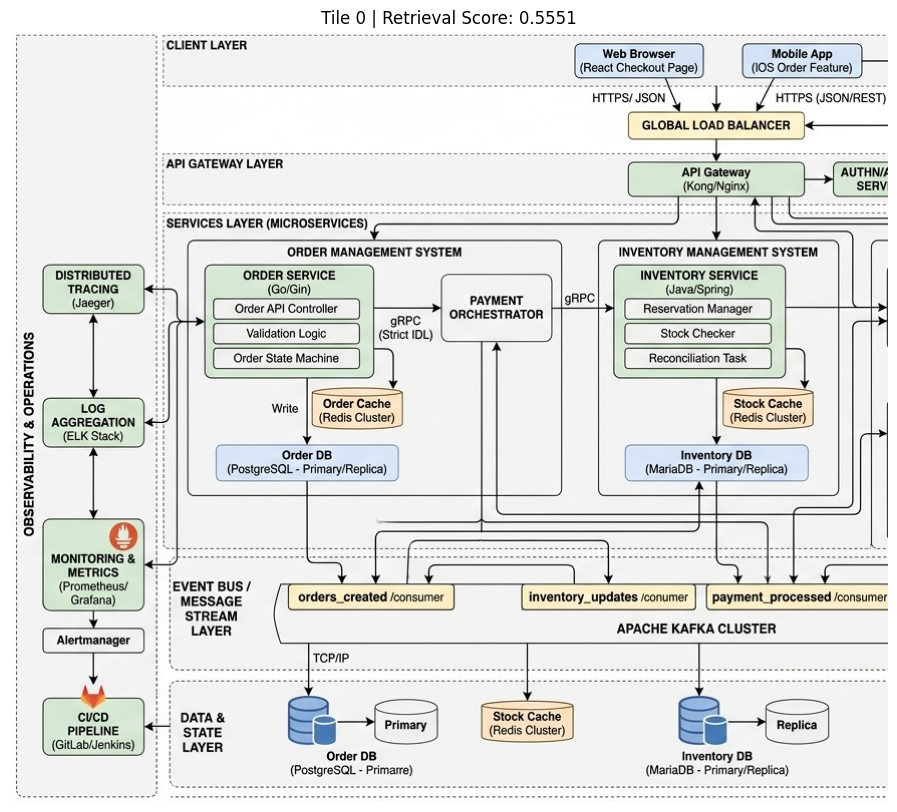

Image dimensions: 875 x 768 pixels

VLM CAPTION:
----------------------------------------------------------------------------------------------------
**OVERVIEW**

* Title: Technical Diagram
* Diagram Type: Complex System Architecture
* Overall Layout: Hierarchical with multiple layers and interconnected components
* Dominant Flow Direction: Top-down and left-to-right
* Extraction Status: Verified

**ENTITIES**

1. **Client Layer**
	* Label: Web Browser (React Checkout Page)
	* Parent: None
	* Type: Web Browser
	* Metadata: React Checkout Page
	* Position: Top-left
	* Status: Verified
2. **API Gateway Layer**
	* Label: API Gateway (kong/Nginx)
	* Parent: Client Layer
	* Type: API Gateway
	* Metadata: kong/Nginx
	* Position: Top-center
	* Status: Verified
3. **Order Management System**
	* Label: Order Service (Go/Gin)
	* Parent: API Gateway Layer
	* Type: Order Service
	* Metadata: Go/Gin
	* Position: Middle-left
	* Status: Verified
4. **Payment Orchestrator**
	* Label: gRPC (Strict IDL

INFO:pixelrag:START  save_captions_md | {'path': 'captions.md', 'n_hits': 1}
DEBUG:pixelrag:[GPU save_captions_md] used=14.27GB free=1.37GB total=15.64GB


06:18:32 | INFO    | Saved captions.md (3893 bytes)


INFO:pixelrag:Saved captions.md (3893 bytes)


Saved captions.md
06:18:32 | INFO    | DONE   save_captions_md in 0.00s


INFO:pixelrag:DONE   save_captions_md in 0.00s
DEBUG:pixelrag:[GPU save_captions_md (done)] used=14.27GB free=1.37GB total=15.64GB


captions.md written successfully.
Full structured log written to: /content/PixelRAG/pixelrag_run.log
06:18:32 | INFO    | DONE   final_run in 101.60s


INFO:pixelrag:DONE   final_run in 101.60s
DEBUG:pixelrag:[GPU final_run (done)] used=14.27GB free=1.37GB total=15.64GB


In [57]:
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

with stage("final_run"):
    if not queries:
        logger.error("`queries` is empty nothing to run. Re-run cell 12 or 14.")
        raise RuntimeError("Empty queries list.")

    query = queries[0]
    hits = caption_search_result(query, top_k=1)

    n_ok = sum(
        1
        for h in hits
        if not str(h.get("vlm_text", "")).startswith("[captioning failed")
    )

    logger.info(
        f"Final run summary: {n_ok}/{len(hits)} tiles captioned successfully"
    )

    for h in hits:
        score = h.get("score")
        score_str = (
            f"{score:.4f}"
            if isinstance(score, (int, float))
            else "n/a"
        )

        tile_index = h.get("tile_index")
        tile_path = resolve_tile_path(h)

        print("=" * 100)
        print(f"TILE INSPECTION")
        print(f"tile_index : {tile_index}")
        print(f"score      : {score_str}")
        print(f"tile_path  : {tile_path}")
        print("=" * 100)

        # Inspect the exact tile being sent for captioning
        if tile_path and Path(tile_path).exists():
            image = Image.open(tile_path).convert("RGB")

            plt.figure(figsize=(16, 10))
            plt.imshow(image)
            plt.title(
                f"Tile {tile_index} | Retrieval Score: {score_str}"
            )
            plt.axis("off")
            plt.show()

            print(
                f"Image dimensions: {image.width} x {image.height} pixels\n"
            )
        else:
            print(
                f"[WARNING] Could not locate tile image: {tile_path}\n"
            )

        print("VLM CAPTION:")
        print("-" * 100)
        print(h.get("vlm_text", "")[:2000])
        print("\n")

    save_captions_md(query, hits, path="captions.md")

    print(f"captions.md written successfully.")
    print(f"Full structured log written to: {LOG_PATH.resolve()}")

In [58]:
from google.colab import files

output_path = save_captions_md(query, hits)
files.download(output_path)

06:18:51 | INFO    | START  save_captions_md | {'path': 'captions.md', 'n_hits': 1}


INFO:pixelrag:START  save_captions_md | {'path': 'captions.md', 'n_hits': 1}
DEBUG:pixelrag:[GPU save_captions_md] used=14.27GB free=1.37GB total=15.64GB


06:18:51 | INFO    | Saved captions.md (3893 bytes)


INFO:pixelrag:Saved captions.md (3893 bytes)


Saved captions.md
06:18:51 | INFO    | DONE   save_captions_md in 0.00s


INFO:pixelrag:DONE   save_captions_md in 0.00s
DEBUG:pixelrag:[GPU save_captions_md (done)] used=14.27GB free=1.37GB total=15.64GB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>